In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys
from datetime import date

In [2]:
pd.reset_option('all')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


C:\Users\Korisnik\AppData\Local\Temp\ipykernel_20172\1788277109.py:1: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_20172\1788277109.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [3]:
for root, dirs, files in os.walk('../data/data_from_db_as_csv'):
    print("Folder:", root)
    print("Podfolderi:", dirs)
    print("Fajlovi:", files)
    print()

Folder: ../data/data_from_db_as_csv
Podfolderi: []
Fajlovi: ['new_polisa_202603141519.csv', 'new_polisa_klijent_202603141515.csv', 'new_polisa_klijent_version_202603141517.csv', 'new_polisa_uloga_202603172039.csv', 'stete_new_202603141531.csv', 'stete_new_klijent_202603141321.csv', 'tsif_djelatnost_202603200015.csv', '__ins_klijenti__202603141320.csv']



In [4]:
np_df = pd.read_csv('../data/data_from_db_as_csv/new_polisa_202603141519.csv', dtype = {
    'ponuda_id': 'Int64',
    'ugo_jmbg': str
})

ins_cli_df = pd.read_csv('../data/data_from_db_as_csv/__ins_klijenti__202603141320.csv', dtype = {
    'mat_br': str,
    'klijent_id': 'Int64'
})

np_cli_df = pd.read_csv('../data/data_from_db_as_csv/new_polisa_klijent_202603141515.csv',
    dtype={
        'osig_jmbg': str,
        'klijent_id': 'Int64',
        'ponuda_id': 'Int64'
    })

C:\Users\Korisnik\AppData\Local\Temp\ipykernel_20172\3284326539.py:1: DtypeWarning: Columns (61,65,80,82) have mixed types. Specify dtype option on import or set low_memory=False.
  np_df = pd.read_csv('../data/data_from_db_as_csv/new_polisa_202603141519.csv', dtype = {
C:\Users\Korisnik\AppData\Local\Temp\ipykernel_20172\3284326539.py:11: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  np_cli_df = pd.read_csv('../data/data_from_db_as_csv/new_polisa_klijent_202603141515.csv',


In [5]:
print(ins_cli_df.shape)
print(np_cli_df.shape)
print(np_df.shape)

(54967, 17)
(114343, 31)
(97938, 87)


In [6]:
ins_cli_df[ins_cli_df['klijent_id'] == 323]

,klijent_id,ind_rezident,sif_svojina,mat_br,naziv,naziv1,king_id,ind_stranac,drzava_id,br_pasosa,datum_rodjenja,pol_id,dat_vozacke,sif_delatnost,nedef_delatnost,sif_bracni_status,mesto_rodj
236,323,N,2,4400855640000,ODS ELEKTROKRAJINA AD BANJALUKA,NaN,701217.0,NaN,NaN,NaN,NaN,NaN,NaN,285.0,NaN,NaN,NaN


In [6]:
np_cli_df = np_cli_df.sort_values(by=['klijent_id'], ascending=[True])

In [7]:
ins_cli_df = ins_cli_df.sort_values(by=['klijent_id'], ascending=[True])

In [8]:
def skupi_info_po_klijentu(df):
    """
    Za svakog klijenta uzmi sve redove i skupi sve ne-null 
    vrijednosti u jedan red.
    Ako ista kolona ima više različitih vrijednosti — uzmi najčešću.
    """
    def prvi_ne_null(series):
        val = series.dropna()
        return val.iloc[0] if len(val) > 0 else np.nan

    return df.groupby('klijent_id').agg(prvi_ne_null)


np_cli_clean = skupi_info_po_klijentu(np_cli_df.reset_index())

print(f"Prije: {np_cli_df.shape[0]} redova")
print(f"Poslije: {np_cli_clean.shape[0]} redova (jedinstveni klijenti)")
print(f"\nPopunjenost (% ne-null):")
print((np_cli_clean.notna().mean() * 100).round(1).to_string())

Prije: 114343 redova
Poslije: 54109 redova (jedinstveni klijenti)

Popunjenost (% ne-null):
index                100.0
ponuda_id            100.0
redni_br             100.0
sif_uloga            100.0
osig_jmbg             99.2
osig_svojina         100.0
osig_naziv           100.0
osig_naziv1           89.5
osig_ulica            99.5
osig_kuc_br           99.6
osig_mesto           100.0
osig_posta           100.0
osig_kanton           99.1
osig_opstina          99.1
osig_mesto_id         99.1
osig_telefon1         56.3
osig_telefon2          0.0
osig_mail             17.5
king_id               94.7
drzava_id              0.8
br_pasosa              0.8
datum_rodjenja         0.8
pol_id                89.5
ind_info_ponuda      100.0
dat_vozacke           10.8
sif_delatnost          4.4
nedef_delatnost        0.0
sif_bracni_status     11.7
mesto_rodj            11.8
procenat               0.0
sif_mj                 0.0


In [9]:
# join — kraće, radi jer je klijent_id index
profil = ins_cli_df.join(np_cli_clean, how='left', rsuffix='_np')

In [10]:
profil['mat_br'] = profil['mat_br'].astype(str)

In [11]:
# 1. Izvedi starost iz mat_br
def izvedi_starost(mat_br):
    mb = str(mat_br).zfill(13)
    god = int(mb[4:7])
    god = (2000 + god) if god < 800 else (1000 + god)
    age = date.today().year - god
    return age


profil['starost'] = profil[profil['osig_svojina'] == 1]['mat_br'].apply(izvedi_starost)

# 2. Dopuni prazna polja iz _np kolona
profil['pol_id']           = profil['pol_id'].fillna(profil['pol_id_np'])
profil['dat_vozacke']      = profil['dat_vozacke'].fillna(profil['dat_vozacke_np'])
profil['sif_bracni_status']= profil['sif_bracni_status'].fillna(profil['sif_bracni_status_np'])
profil['mesto_rodj']       = profil['mesto_rodj'].fillna(profil['mesto_rodj_np'])
profil['sif_delatnost']    = profil['sif_delatnost'].fillna(profil['sif_delatnost_np'])

# 3. Izvedi binary feature-e
profil['ima_telefon']      = profil['osig_telefon1'].notna().astype(int)
profil['ima_email']        = profil['osig_mail'].notna().astype(int)
profil['ima_vozacku']      = profil['dat_vozacke'].notna().astype(int)
profil['je_fizicko_lice']  = (profil['sif_svojina'] == 1).astype(int)

# 4. Zadržи samo korisne kolone
finalne_kolone = [
    'starost', 'pol_id', 'je_fizicko_lice',
    'sif_delatnost', 'sif_bracni_status',
    'ima_telefon', 'ima_email', 'ima_vozacku',
    'osig_mesto', 'osig_opstina', 'osig_kanton',
    'mesto_rodj', 'ponuda_id'
]
profil_clean = profil[finalne_kolone]

# 5. Provjera
print(profil_clean.shape)
print((profil_clean.notna().mean() * 100).round(1).to_string())

(54967, 13)
starost               86.2
pol_id                98.1
je_fizicko_lice      100.0
sif_delatnost          8.2
sif_bracni_status     21.5
ima_telefon          100.0
ima_email            100.0
ima_vozacku          100.0
osig_mesto            96.2
osig_opstina          95.4
osig_kanton           95.4
mesto_rodj            21.7
ponuda_id             96.2


In [12]:
profil_polisa = np_df.merge(profil, on='ponuda_id', how='left')

In [13]:
profil_polisa.notna().sum()

ponuda_id                  98810
polisa_id                  98810
sif_vrsta                  98810
polisa_no                  98810
broker_id                  98810
sif_org_jed                98810
zamena_polise_no           98797
ind_zamena                 98810
sif_preuzmi                26600
preuzmi_no                 25469
preuzmi_id                 98810
ugo_jmbg                   90732
ugo_svojina                91481
ugo_naziv                  91333
ugo_naziv1                 67747
ugo_ulica                  91012
ugo_kuc_br                 91053
ugo_mesto                  90762
ugo_posta                  90922
ugo_kanton                 90844
ugo_opstina                90554
ugo_mesto_id               90337
ugo_telefon1               57159
ugo_telefon2                   0
ugo_mail                   15464
osig_jmbg_x                 6082
osig_svojina_x              6488
osig_naziv_x                6116
osig_naziv1_x               2973
osig_ulica_x                6115
osig_kuc_b

In [14]:
len(profil_polisa)

98810

In [15]:
# Provjeri koje kolone su duplirane
duplirane = [c for c in profil_polisa.columns if c.endswith('_x') or c.endswith('_y')]
print(duplirane)

['osig_jmbg_x', 'osig_svojina_x', 'osig_naziv_x', 'osig_naziv1_x', 'osig_ulica_x', 'osig_kuc_br_x', 'osig_mesto_x', 'osig_posta_x', 'osig_kanton_x', 'osig_opstina_x', 'osig_mesto_id_x', 'osig_telefon1_x', 'osig_telefon2_x', 'osig_mail_x', 'king_id_x', 'king_id_y', 'osig_jmbg_y', 'osig_svojina_y', 'osig_naziv_y', 'osig_naziv1_y', 'osig_ulica_y', 'osig_kuc_br_y', 'osig_mesto_y', 'osig_posta_y', 'osig_kanton_y', 'osig_opstina_y', 'osig_mesto_id_y', 'osig_telefon1_y', 'osig_telefon2_y', 'osig_mail_y']


In [16]:
# Izbaci sve _x kolone
kolone_za_brisanje = [c for c in profil_polisa.columns if c.endswith('_x')]
profil_polisa = profil_polisa.drop(columns=kolone_za_brisanje)

# Preimenuj _y kolone u originalna imena
profil_polisa.columns = [c.replace('_y', '') if c.endswith('_y') else c 
                          for c in profil_polisa.columns]

print(profil_polisa.shape)
print(profil_polisa.columns.tolist())

(98810, 124)
['ponuda_id', 'polisa_id', 'sif_vrsta', 'polisa_no', 'broker_id', 'sif_org_jed', 'zamena_polise_no', 'ind_zamena', 'sif_preuzmi', 'preuzmi_no', 'preuzmi_id', 'ugo_jmbg', 'ugo_svojina', 'ugo_naziv', 'ugo_naziv1', 'ugo_ulica', 'ugo_kuc_br', 'ugo_mesto', 'ugo_posta', 'ugo_kanton', 'ugo_opstina', 'ugo_mesto_id', 'ugo_telefon1', 'ugo_telefon2', 'ugo_mail', 'sif_trajanja', 'dat_od_ug', 'dat_do_ug', 'dat_od', 'dat_do', 'time_od', 'time_do', 'br_dana', 'mesto_izdavanja', 'dat_izdavanja', 'mjesto_izdavanja', 'napomena', 'napomena_auto', 'napomena1', 'p_oper', 'p_date', 'p_session_id', 'sif_nac_plac', 'br_rata', 'dat_prve_rate', 'sif_napomena', 'premija_ukupno', 'opis_osiguravac', 'ind_user_skadenca', 'ind_obracun', 'suma_osiguranja', 'polisa_tarifa', 'veza_polise_no', 'ind_lock_skadenca', 'miro_polisa_no', 'uw_indikator', 'ind_uw_kontrola', 'ugo_isprava', 'osig_isprava', 'sif_ikanton', 'sif_iopstina', 'ugo_del', 'sif_datum_dospeca', 'sif_bankovni_racun', 'ugo_br_pasosa', 'osig_br_p

In [17]:
korisne_kolone = [
    # Identifikatori
    'ponuda_id', 'klijent_id', 'sif_vrsta',
    
    # Podaci o polisi
    'broker_id', 'sif_org_jed',
    'ind_zamena', 'ind_dug', 'ind_steta',
    'sif_trajanja', 'dat_od', 'dat_do', 'br_dana',
    'dat_izdavanja',
    'premija_ukupno', 'konacna_premija', 'suma_osiguranja',
    'br_rata', 'sif_nac_plac',
    'uw_indikator',
    
    # Profil klijenta
    'starost', 'pol_id', 'je_fizicko_lice',
    'ima_telefon', 'ima_email', 'ima_vozacku',
    'osig_mesto', 'osig_opstina', 'osig_kanton',
    'sif_delatnost', 'sif_bracni_status',
]

profil_polisa_clean = profil_polisa[
    [c for c in korisne_kolone if c in profil_polisa.columns]
]

print(profil_polisa_clean.shape)
print(profil_polisa_clean.notna().sum().to_string())

(98810, 30)
ponuda_id            98810
klijent_id           52886
sif_vrsta            98810
broker_id            98810
sif_org_jed          98810
ind_zamena           98810
ind_dug              98810
ind_steta            98810
sif_trajanja         91288
dat_od               91292
dat_do               91292
br_dana              76457
dat_izdavanja        98810
premija_ukupno       98810
konacna_premija      79294
suma_osiguranja      96476
br_rata              87037
sif_nac_plac         87037
uw_indikator         98810
starost              47358
pol_id               52089
je_fizicko_lice      52886
ima_telefon          52886
ima_email            52886
ima_vozacku          52886
osig_mesto           52862
osig_opstina         52432
osig_kanton          52438
sif_delatnost         4405
sif_bracni_status    11584


In [18]:
# Dodaj klijent_id ako nije tu
profil_polisa_clean = profil_polisa_clean.copy()
profil_polisa_clean['klijent_id'] = profil_polisa.index

# Izbaci kolone sa premalo podataka
profil_polisa_clean = profil_polisa_clean.drop(
    columns=['sif_delatnost', 'sif_bracni_status']
)

print(profil_polisa_clean.shape)

(98810, 28)


In [19]:
print(profil_polisa_clean.columns.tolist())
print(f"Jedinstvenih klijenata: {profil_polisa_clean['klijent_id'].nunique()}")
print(f"Jedinstvenih vrsta polisa: {profil_polisa_clean['sif_vrsta'].nunique()}")
print(f"Klijenti bez klijent_id: {profil_polisa_clean['klijent_id'].isna().sum()}")

['ponuda_id', 'klijent_id', 'sif_vrsta', 'broker_id', 'sif_org_jed', 'ind_zamena', 'ind_dug', 'ind_steta', 'sif_trajanja', 'dat_od', 'dat_do', 'br_dana', 'dat_izdavanja', 'premija_ukupno', 'konacna_premija', 'suma_osiguranja', 'br_rata', 'sif_nac_plac', 'uw_indikator', 'starost', 'pol_id', 'je_fizicko_lice', 'ima_telefon', 'ima_email', 'ima_vozacku', 'osig_mesto', 'osig_opstina', 'osig_kanton']
Jedinstvenih klijenata: 98810
Jedinstvenih vrsta polisa: 15
Klijenti bez klijent_id: 0


In [20]:
print(profil_polisa.index.name)
print(profil_polisa.index[:5])

None
RangeIndex(start=0, stop=5, step=1)


In [21]:
print('klijent_id' in np_df.columns)
print('klijent_id' in profil.columns)
print('klijent_id' in profil_polisa.columns)

False
True
True


In [23]:
# Ponovi cijeli merge od početka sa reset_index()
veza = np_cli_df.reset_index()[['klijent_id', 'ponuda_id']].drop_duplicates()

profil_polisa = np_df.merge(veza, on='ponuda_id', how='left')
profil_polisa = profil_polisa.merge(profil_clean.reset_index(), on='ponuda_id', how='left')

# Očisti duplirane kolone
kolone_za_brisanje = [c for c in profil_polisa.columns if c.endswith('_x')]
profil_polisa = profil_polisa.drop(columns=kolone_za_brisanje)
profil_polisa.columns = [c.replace('_y', '') if c.endswith('_y') else c 
                          for c in profil_polisa.columns]

print(f"Jedinstvenih klijenata: {profil_polisa['klijent_id'].nunique()}")
print(f"Redova: {len(profil_polisa)}")

Jedinstvenih klijenata: 54109
Redova: 123431


In [24]:
korisne_kolone = [
    'klijent_id', 'ponuda_id', 'sif_vrsta',
    'broker_id', 'sif_org_jed',
    'ind_zamena', 'ind_dug', 'ind_steta',
    'sif_trajanja', 'dat_od', 'dat_do', 'br_dana',
    'dat_izdavanja',
    'premija_ukupno', 'konacna_premija', 'suma_osiguranja',
    'br_rata', 'sif_nac_plac', 'uw_indikator',
    'starost', 'pol_id', 'je_fizicko_lice',
    'ima_telefon', 'ima_email', 'ima_vozacku',
    'osig_mesto', 'osig_opstina', 'osig_kanton',
]

profil_polisa_clean = profil_polisa[
    [c for c in korisne_kolone if c in profil_polisa.columns]
]

print(profil_polisa_clean.shape)
print(f"Jedinstvenih klijenata: {profil_polisa_clean['klijent_id'].nunique()}")
print(f"Vrsta polisa: {profil_polisa_clean['sif_vrsta'].nunique()}")
print(profil_polisa_clean.notna().sum().to_string())

(123431, 28)
Jedinstvenih klijenata: 54109
Vrsta polisa: 15
klijent_id         115816
ponuda_id          123431
sif_vrsta          123431
broker_id          123431
sif_org_jed        123431
ind_zamena         123431
ind_dug            123431
ind_steta          123431
sif_trajanja       115895
dat_od             115899
dat_do             115899
br_dana             86252
dat_izdavanja      123431
premija_ukupno     123431
konacna_premija     85905
suma_osiguranja    121096
br_rata            110919
sif_nac_plac       110919
uw_indikator       123431
starost             66046
pol_id              72082
je_fizicko_lice     73163
ima_telefon         73163
ima_email           73163
ima_vozacku         73163
osig_mesto          73123
osig_opstina        72678
osig_kanton         72684


In [25]:
# Polise bez klijent_id
bez_klijenta = profil_polisa_clean[profil_polisa_clean['klijent_id'].isna()]
print(f"Polise bez klijent_id: {len(bez_klijenta)}")
print(f"Unique sif_vrsta bez klijenta: {bez_klijenta['sif_vrsta'].unique()}")

Polise bez klijent_id: 7615
Unique sif_vrsta bez klijenta: [ 0  6  9  1 12  7  5 17 15  8 13 23 22 11  4]


In [26]:
fizicka = profil_polisa_clean[profil_polisa_clean['je_fizicko_lice'] == 1]
print(f"Fizička lica: {len(fizicka)}")
print(f"Starost popunjena: {fizicka['starost'].notna().sum()} ({fizicka['starost'].notna().mean():.1%})")

Fizička lica: 65528
Starost popunjena: 59490 (90.8%)


In [27]:
# Izbaci polise bez klijent_id
profil_polisa_clean = profil_polisa_clean[
    profil_polisa_clean['klijent_id'].notna()
].copy()

print(f"Redova nakon čišćenja: {len(profil_polisa_clean)}")
print(f"Jedinstvenih klijenata: {profil_polisa_clean['klijent_id'].nunique()}")

Redova nakon čišćenja: 115816
Jedinstvenih klijenata: 54109


In [28]:
# Sortiraj po klijentu i datumu (važno za 'last')
profil_polisa_clean['dat_izdavanja'] = pd.to_datetime(profil_polisa_clean['dat_izdavanja'])
profil_polisa_clean = profil_polisa_clean.sort_values(['klijent_id', 'dat_izdavanja'])

# Agregacija
agg = profil_polisa_clean.groupby('klijent_id').agg(
    # Premija i suma
    premija_ukupno_sum     = ('premija_ukupno', 'sum'),
    premija_ukupno_mean    = ('premija_ukupno', 'mean'),
    premija_ukupno_max     = ('premija_ukupno', 'max'),
    premija_ukupno_zadnja  = ('premija_ukupno', 'last'),
    konacna_premija_sum    = ('konacna_premija', 'sum'),
    konacna_premija_mean   = ('konacna_premija', 'mean'),
    konacna_premija_zadnja = ('konacna_premija', 'last'),
    suma_osig_sum          = ('suma_osiguranja', 'sum'),
    suma_osig_mean         = ('suma_osiguranja', 'mean'),
    suma_osig_max          = ('suma_osiguranja', 'max'),
    suma_osig_zadnja       = ('suma_osiguranja', 'last'),

    # Polisa info
    broj_polisa            = ('ponuda_id', 'count'),
    broj_vrsta             = ('sif_vrsta', 'nunique'),
    ima_stetu              = ('ind_steta', lambda x: int((x == 'D').any())),
    ima_dug                = ('ind_dug',   lambda x: int((x == 'D').any())),
    ima_zamjenu            = ('ind_zamena',lambda x: int((x == 'D').any())),
    broj_steta             = ('ind_steta', lambda x: (x == 'D').sum()),
    broj_zamjena           = ('ind_zamena',lambda x: (x == 'D').sum()),
    br_rata_mean           = ('br_rata', 'mean'),

    # Demografija (ista za sve redove klijenta, uzmi first)
    starost                = ('starost', 'first'),
    pol_id                 = ('pol_id', 'first'),
    je_fizicko_lice        = ('je_fizicko_lice', 'first'),
    ima_telefon            = ('ima_telefon', 'first'),
    ima_email              = ('ima_email', 'first'),
    ima_vozacku            = ('ima_vozacku', 'first'),
    osig_mesto             = ('osig_mesto', 'first'),
    osig_opstina           = ('osig_opstina', 'first'),
    osig_kanton            = ('osig_kanton', 'first'),
).reset_index()

print(agg.shape)
print(agg.head(3))

(54109, 29)
   klijent_id  premija_ukupno_sum  premija_ukupno_mean  premija_ukupno_max  \
0           1             2794.58           931.526667             1042.29   
1           2            25886.04          1125.480000            14715.00   
2           3              472.35           157.450000              437.35   

   premija_ukupno_zadnja  konacna_premija_sum  konacna_premija_mean  \
0                1042.29              3126.87           1042.290000   
1                3226.50               375.93             17.087727   
2                 437.35                 0.00              0.000000   

   konacna_premija_zadnja  suma_osig_sum  suma_osig_mean  suma_osig_max  \
0                 1042.29     2518048.00   839349.333333      2400000.0   
1                    0.00     6032970.04   262303.045217      2400000.0   
2                    0.00      792000.00   264000.000000       792000.0   

   suma_osig_zadnja  broj_polisa  broj_vrsta  ima_stetu  ima_dug  ima_zamjenu  \
0       

In [29]:
# Wide format — vrsta polise po klijentu (0/1)
vrste_dummies = (
    profil_polisa_clean
    .groupby(['klijent_id', 'sif_vrsta'])
    .size()
    .unstack(fill_value=0)
    .clip(upper=1)
    .add_prefix('vrsta_')
    .reset_index()
)

# Spoji sa agregacijom
finalni_dataset = agg.merge(vrste_dummies, on='klijent_id', how='left')

print(finalni_dataset.shape)
print(f"Vrste polisa kolone: {[c for c in finalni_dataset.columns if c.startswith('vrsta_')]}")

(54109, 44)
Vrste polisa kolone: ['vrsta_0', 'vrsta_1', 'vrsta_4', 'vrsta_5', 'vrsta_6', 'vrsta_7', 'vrsta_8', 'vrsta_9', 'vrsta_11', 'vrsta_12', 'vrsta_13', 'vrsta_15', 'vrsta_17', 'vrsta_22', 'vrsta_23']


In [30]:
# Koliko klijenata ima vrstu 0
print(f"Klijenata sa vrsta_0: {(finalni_dataset['vrsta_0'] == 1).sum()}")

# Pogledaj te polise u originalnim podacima
polise_vrsta_0 = profil_polisa_clean[profil_polisa_clean['sif_vrsta'] == 0]
print(f"Polisa vrste 0: {len(polise_vrsta_0)}")
print(polise_vrsta_0[['sif_vrsta', 'premija_ukupno', 'konacna_premija', 'suma_osiguranja']].describe())

Klijenata sa vrsta_0: 1534
Polisa vrste 0: 2580
       sif_vrsta  premija_ukupno  konacna_premija  suma_osiguranja
count     2580.0     2580.000000      2119.000000     2.573000e+03
mean         0.0     2379.092884      2507.804087     8.814008e+04
std          0.0     3266.812332      3379.737324     9.135022e+04
min          0.0        0.000000         0.000000     0.000000e+00
25%          0.0      854.260000       933.490000     4.290598e+04
50%          0.0     1401.460000      1450.300000     6.140400e+04
75%          0.0     2568.957500      2718.010000     1.062120e+05
max          0.0    49508.860000     49508.860000     1.015910e+06


In [31]:
finalni_dataset.to_csv("finalni_dataset.csv", index=False)
print(f"✓ Sačuvano! {finalni_dataset.shape}")

✓ Sačuvano! (54109, 44)


In [32]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [38]:
# Vrati se na profil_polisa_clean (red po polisi)
# i napravi split po datumu

profil_polisa_clean['dat_izdavanja'] = pd.to_datetime(profil_polisa_clean['dat_izdavanja'])
profil_polisa_clean = profil_polisa_clean.sort_values(['klijent_id', 'dat_izdavanja'])
profil_polisa_clean = profil_polisa_clean.reset_index(drop=True)

# Za svakog klijenta — zadnja polisa je target, ostale su feature-i
zadnja = profil_polisa_clean.groupby('klijent_id').last()['sif_vrsta'].reset_index()
zadnja.columns = ['klijent_id', 'target_vrsta']

historija = profil_polisa_clean.groupby('klijent_id', group_keys=False).apply(
    lambda x: x.iloc[:-1]
)
historija.index.name = None
historija = historija.reset_index()
historija = historija.rename(columns={'index': 'klijent_id'})

print(f"Klijenata sa historijom: {historija['klijent_id'].nunique()}")
print(f"Klijenata s 1 polisom:   {(profil_polisa_clean.groupby('klijent_id').size() == 1).sum()}")

Klijenata sa historijom: 61707
Klijenata s 1 polisom:   38852


In [39]:
print(profil_polisa_clean.columns.tolist())

['klijent_id', 'ponuda_id', 'sif_vrsta', 'broker_id', 'sif_org_jed', 'ind_zamena', 'ind_dug', 'ind_steta', 'sif_trajanja', 'dat_od', 'dat_do', 'br_dana', 'dat_izdavanja', 'premija_ukupno', 'konacna_premija', 'suma_osiguranja', 'br_rata', 'sif_nac_plac', 'uw_indikator', 'starost', 'pol_id', 'je_fizicko_lice', 'ima_telefon', 'ima_email', 'ima_vozacku', 'osig_mesto', 'osig_opstina', 'osig_kanton']


In [41]:
# Feature-i bez ijedne vrsta_ kolone
feature_cols_clean = [c for c in finalni_dataset.columns 
                      if not c.startswith('vrsta_') 
                      and c != 'klijent_id']

print(f"Feature-i: {feature_cols_clean}")

X = finalni_dataset[feature_cols_clean].values

Feature-i: ['premija_ukupno_sum', 'premija_ukupno_mean', 'premija_ukupno_max', 'premija_ukupno_zadnja', 'konacna_premija_sum', 'konacna_premija_mean', 'konacna_premija_zadnja', 'suma_osig_sum', 'suma_osig_mean', 'suma_osig_max', 'suma_osig_zadnja', 'broj_polisa', 'broj_vrsta', 'ima_stetu', 'ima_dug', 'ima_zamjenu', 'broj_steta', 'broj_zamjena', 'br_rata_mean', 'starost', 'pol_id', 'je_fizicko_lice', 'ima_telefon', 'ima_email', 'ima_vozacku', 'osig_mesto', 'osig_opstina', 'osig_kanton']


In [42]:
pip install mlxtend

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imbalanced-learn 0.13.0 requires sklearn-compat<1,>=0.1, which is not installed.
mlflow 3.8.1 requires pandas<3, but you have pandas 3.0.1 which is incompatible.



  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [43]:
from mlxtend.frequent_patterns import apriori, association_rules

# Uzmi samo vrsta_ kolone
vrste_matrix = finalni_dataset[[c for c in finalni_dataset.columns 
                                 if c.startswith('vrsta_')]].astype(bool)

# Pronađi česte kombinacije
frequent_itemsets = apriori(vrste_matrix, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.2)
rules = rules.sort_values('lift', ascending=False)

print(f"Broj pravila: {len(rules)}")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20))

Broj pravila: 4
             antecedents            consequents   support  confidence  \
3   frozenset({vrsta_1})  frozenset({vrsta_22})  0.010608    0.036689   
2  frozenset({vrsta_22})   frozenset({vrsta_1})  0.010608    0.775676   
1   frozenset({vrsta_1})   frozenset({vrsta_6})  0.031732    0.109748   
0   frozenset({vrsta_6})   frozenset({vrsta_1})  0.031732    0.437675   

       lift  
3  2.682712  
2  2.682712  
1  1.513721  
0  1.513721  


In [44]:
dist = profil_polisa_clean.groupby('klijent_id').size()
print(dist.value_counts().sort_index().head(10))
print(f"\nUkupno klijenata sa 2+ polise: {(dist >= 2).sum()}")
print(f"Ukupno klijenata sa 3+ polise: {(dist >= 3).sum()}")
print(f"Ukupno klijenata sa 5+ polise: {(dist >= 5).sum()}")

1     38852
2      9044
3      2943
4      1367
5       633
6       390
7       222
8       147
9       109
10       56
Name: count, dtype: int64

Ukupno klijenata sa 2+ polise: 15257
Ukupno klijenata sa 3+ polise: 6213
Ukupno klijenata sa 5+ polise: 1903


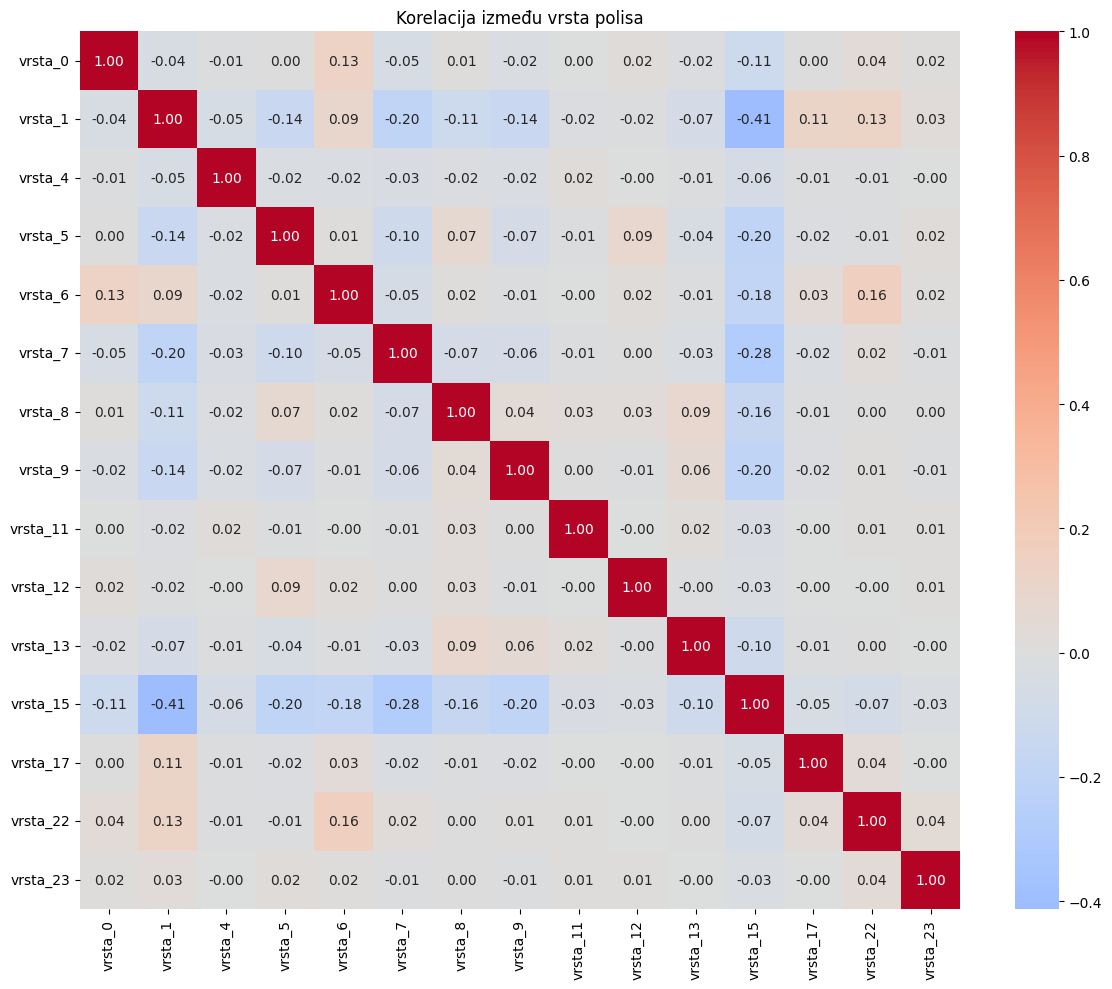


Najveće pozitivne korelacije:
vrsta_6   vrsta_22    0.163440
vrsta_22  vrsta_6     0.163440
vrsta_6   vrsta_0     0.130446
vrsta_0   vrsta_6     0.130446
vrsta_22  vrsta_1     0.126369
vrsta_1   vrsta_22    0.126369
          vrsta_17    0.112458
vrsta_17  vrsta_1     0.112458
vrsta_1   vrsta_6     0.091602
vrsta_6   vrsta_1     0.091602
dtype: float64


In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

vrste_matrix_int = finalni_dataset[[c for c in finalni_dataset.columns 
                                     if c.startswith('vrsta_')]].astype(int)

korelacija = vrste_matrix_int.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(korelacija, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Korelacija između vrsta polisa')
plt.tight_layout()
plt.show()

# Koje vrste su najviše korelirane
print("\nNajveće pozitivne korelacije:")
corr_pairs = korelacija.unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print(corr_pairs.head(10))

In [46]:
# Za svaku vrstu polise — koja je prosječna starost, premija, pol klijenata koji je imaju
for vrsta in [c for c in finalni_dataset.columns if c.startswith('vrsta_')]:
    ima = finalni_dataset[finalni_dataset[vrsta] == 1]
    print(f"{vrsta}: n={len(ima):5d} | "
          f"starost={ima['starost'].mean():.0f} | "
          f"premija={ima['premija_ukupno_mean'].mean():.0f} | "
          f"fizicko={ima['je_fizicko_lice'].mean():.0%} | "
          f"vozacka={ima['ima_vozacku'].mean():.0%}")

vrsta_0: n= 1534 | starost=-50 | premija=1991 | fizicko=68% | vozacka=11%
vrsta_1: n=15645 | starost=17 | premija=402 | fizicko=90% | vozacka=42%
vrsta_4: n=  376 | starost=23 | premija=84 | fizicko=91% | vozacka=16%
vrsta_5: n= 4473 | starost=16 | premija=605 | fizicko=89% | vozacka=12%
vrsta_6: n= 3923 | starost=-15 | premija=1416 | fizicko=78% | vozacka=22%
vrsta_7: n= 8836 | starost=19 | premija=85 | fizicko=91% | vozacka=15%
vrsta_8: n= 3000 | starost=19 | premija=886 | fizicko=89% | vozacka=12%
vrsta_9: n= 4519 | starost=19 | premija=286 | fizicko=90% | vozacka=14%
vrsta_11: n=  140 | starost=23 | premija=137 | fizicko=92% | vozacka=17%
vrsta_12: n=  112 | starost=-21 | premija=2547 | fizicko=79% | vozacka=10%
vrsta_13: n= 1386 | starost=21 | premija=235 | fizicko=90% | vozacka=11%
vrsta_15: n=17126 | starost=18 | premija=681 | fizicko=90% | vozacka=11%
vrsta_17: n=  288 | starost=24 | premija=319 | fizicko=91% | vozacka=88%
vrsta_22: n=  740 | starost=1 | premija=372 | fizicko=8

In [51]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
df_model = finalni_dataset.copy()

for col in ['osig_mesto', 'osig_opstina', 'osig_kanton']:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('NEPOZNATO').astype(str)
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

In [55]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# df_model = finalni_dataset
df_model = finalni_dataset.copy()

# Enkoduj kategoričke
for col in ['osig_mesto', 'osig_opstina', 'osig_kanton']:
    df_model[col] = df_model[col].fillna('NEPOZNATO').astype(str)
    df_model[col] = df_model[col].apply(
        lambda x: x if x in set(encoders[col].classes_) else 'NEPOZNATO'
    )
    df_model[col] = encoders[col].transform(df_model[col])

# Feature-i
feature_cols_demo = [
    'starost', 'pol_id', 'je_fizicko_lice',
    'ima_telefon', 'ima_email', 'ima_vozacku',
    'osig_mesto', 'osig_opstina', 'osig_kanton'
]

vrste = [c for c in finalni_dataset.columns if c.startswith('vrsta_')]
modeli = {}
auc_scores = {}

for vrsta in vrste:
    y = df_model[vrsta].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    if n_pos < 50:
        print(f"⚠ Preskačem {vrsta} — samo {n_pos} pozitivnih")
        continue

    X = df_model[feature_cols_demo].fillna(0).values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = round(n_neg / n_pos, 2),
        eval_metric      = 'auc',
        random_state     = 42,
        verbosity        = 0
    )
    clf.fit(X_train, y_train)
    modeli[vrsta] = clf

    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_scores[vrsta] = round(auc, 4)
    print(f"✓ {vrsta}: AUC={auc:.4f} | pos={n_pos} neg={n_neg}")

print(f"\nProsjek AUC: {np.mean(list(auc_scores.values())):.4f}")

✓ vrsta_0: AUC=0.8542 | pos=1534 neg=52575
✓ vrsta_1: AUC=0.9047 | pos=15645 neg=38464
✓ vrsta_4: AUC=0.9604 | pos=376 neg=53733
✓ vrsta_5: AUC=0.9175 | pos=4473 neg=49636
✓ vrsta_6: AUC=0.7876 | pos=3923 neg=50186
✓ vrsta_7: AUC=0.8047 | pos=8836 neg=45273
✓ vrsta_8: AUC=0.7863 | pos=3000 neg=51109
✓ vrsta_9: AUC=0.7960 | pos=4519 neg=49590
✓ vrsta_11: AUC=0.6935 | pos=140 neg=53969
✓ vrsta_12: AUC=0.8627 | pos=112 neg=53997
✓ vrsta_13: AUC=0.8309 | pos=1386 neg=52723
✓ vrsta_15: AUC=0.9454 | pos=17126 neg=36983
✓ vrsta_17: AUC=0.9307 | pos=288 neg=53821
✓ vrsta_22: AUC=0.7768 | pos=740 neg=53369
✓ vrsta_23: AUC=0.8568 | pos=84 neg=54025

Prosjek AUC: 0.8472


In [56]:
def preporuci_polise(klijent_profil: dict, top_n: int = 5) -> pd.DataFrame:
    """
    klijent_profil = {
        'starost': 42, 'pol_id': 2, 'je_fizicko_lice': 1,
        'ima_telefon': 1, 'ima_email': 0, 'ima_vozacku': 1,
        'osig_mesto': 'Banja Luka', 'osig_opstina': 2.0, 'osig_kanton': 99.0,
        'vec_ima': ['vrsta_1', 'vrsta_7']  # polise koje već ima
    }
    """
    vec_ima = klijent_profil.pop('vec_ima', [])
    
    # Enkoduj kategoričke
    row = klijent_profil.copy()
    for col in ['osig_mesto', 'osig_opstina', 'osig_kanton']:
        if col in encoders:
            val = str(row.get(col, 'NEPOZNATO'))
            known = set(encoders[col].classes_)
            val = val if val in known else 'NEPOZNATO'
            row[col] = encoders[col].transform([val])[0]
        else:
            row[col] = 0

    X_new = np.array([[row.get(c, 0) for c in feature_cols_demo]])

    # Generiši score za svaku vrstu
    scores = {}
    for vrsta, model in modeli.items():
        if vrsta not in vec_ima:
            scores[vrsta] = round(model.predict_proba(X_new)[0][1], 4)

    # Top N preporuka
    rezultat = pd.DataFrame(
        sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n],
        columns=['vrsta_polise', 'score']
    )
    rezultat['rank'] = range(1, len(rezultat) + 1)
    return rezultat[['rank', 'vrsta_polise', 'score']]


# Test
print(preporuci_polise({
    'starost': 42, 'pol_id': 2.0, 'je_fizicko_lice': 1,
    'ima_telefon': 1, 'ima_email': 1, 'ima_vozacku': 1,
    'osig_mesto': 'Banja Luka', 'osig_opstina': 2.0, 'osig_kanton': 99.0,
    'vec_ima': ['vrsta_1', 'vrsta_7']
}))

   rank vrsta_polise   score
0     1      vrsta_9  0.7523
1     2     vrsta_13  0.7374
2     3      vrsta_6  0.6005
3     4      vrsta_0  0.5782
4     5     vrsta_22  0.5733


In [62]:
import pickle

# Sačuvaj modele i enkodere
with open('modeli_osiguranje.pkl', 'wb') as f:
    pickle.dump({
        'modeli': modeli,
        'encoders': encoders,
        'feature_cols': feature_cols_demo
    }, f)
print("✓ Modeli sačuvani")

# Batch preporuke za sve klijente
rezultati = []
for _, row in finalni_dataset.iterrows():
    vec_ima = [c for c in finalni_dataset.columns 
               if c.startswith('vrsta_') and row[c] == 1]
    
    profil = {
        'starost'        : row['starost'],
        'pol_id'         : row['pol_id'],
        'je_fizicko_lice': row['je_fizicko_lice'],
        'ima_telefon'    : row['ima_telefon'],
        'ima_email'      : row['ima_email'],
        'ima_vozacku'    : row['ima_vozacku'],
        'osig_mesto'     : row['osig_mesto'],
        'osig_opstina'   : row['osig_opstina'],
        'osig_kanton'    : row['osig_kanton'],
        'vec_ima'        : vec_ima
    }
    
    recs = preporuci_polise(profil, top_n=5)
    recs['klijent_id'] = row['klijent_id']
    rezultati.append(recs)

preporuke_sve = pd.concat(rezultati, ignore_index=True)
preporuke_sve.to_csv('preporuke_svi_klijenti.csv', index=False)
print(f"✓ Sačuvano {len(preporuke_sve)} preporuka za {preporuke_sve['klijent_id'].nunique()} klijenata")

✓ Modeli sačuvani
✓ Sačuvano 270544 preporuka za 54109 klijenata


In [63]:
feature_cols_kmeans = [
    'starost', 'pol_id', 'je_fizicko_lice',
    'ima_telefon', 'ima_email', 'ima_vozacku',
    'osig_opstina', 'osig_kanton',
    'premija_ukupno_mean', 'suma_osig_mean', 'broj_polisa'
]

popunjeni = finalni_dataset[feature_cols_kmeans].notna().all(axis=1).sum()
print(f"Klijenata sa svim podacima: {popunjeni} od {len(finalni_dataset)}")
print(f"\nPopunjenost po koloni:")
print((finalni_dataset[feature_cols_kmeans].notna().mean() * 100).round(1).to_string())

Klijenata sa svim podacima: 47651 od 54109

Popunjenost po koloni:
starost                 88.9
pol_id                  96.5
je_fizicko_lice         97.8
ima_telefon             97.8
ima_email               97.8
ima_vozacku             97.8
osig_opstina            96.9
osig_kanton             97.0
premija_ukupno_mean    100.0
suma_osig_mean         100.0
broj_polisa            100.0


In [64]:
for vrsta, model in modeli.items():
    X_train_check = df_model[feature_cols_demo].values
    y_train_check = df_model[vrsta].values
    y_prob_train  = model.predict_proba(X_train_check)[:, 1]
    auc_train     = roc_auc_score(y_train_check, y_prob_train)
    print(f"{vrsta}: AUC_train={auc_train:.4f} | AUC_test={auc_scores[vrsta]:.4f} | razlika={auc_train-auc_scores[vrsta]:.4f}")

vrsta_0: AUC_train=0.7949 | AUC_test=0.8542 | razlika=-0.0593
vrsta_1: AUC_train=0.8903 | AUC_test=0.9047 | razlika=-0.0144
vrsta_4: AUC_train=0.9897 | AUC_test=0.9604 | razlika=0.0293
vrsta_5: AUC_train=0.8356 | AUC_test=0.9175 | razlika=-0.0819
vrsta_6: AUC_train=0.7599 | AUC_test=0.7876 | razlika=-0.0277
vrsta_7: AUC_train=0.7869 | AUC_test=0.8047 | razlika=-0.0178
vrsta_8: AUC_train=0.7048 | AUC_test=0.7863 | razlika=-0.0815
vrsta_9: AUC_train=0.8014 | AUC_test=0.7960 | razlika=0.0054
vrsta_11: AUC_train=0.9166 | AUC_test=0.6935 | razlika=0.2231
vrsta_12: AUC_train=0.6458 | AUC_test=0.8627 | razlika=-0.2169
vrsta_13: AUC_train=0.8596 | AUC_test=0.8309 | razlika=0.0287
vrsta_15: AUC_train=0.9356 | AUC_test=0.9454 | razlika=-0.0098
vrsta_17: AUC_train=0.9462 | AUC_test=0.9307 | razlika=0.0155
vrsta_22: AUC_train=0.8415 | AUC_test=0.7768 | razlika=0.0647
vrsta_23: AUC_train=0.7769 | AUC_test=0.8568 | razlika=-0.0799


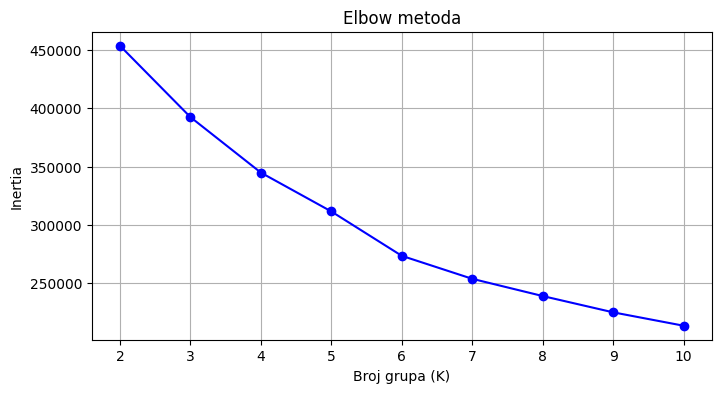

In [65]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Uzmi samo klijente sa svim podacima
df_kmeans = finalni_dataset[feature_cols_kmeans].dropna().copy()

# Skaliraj
scaler_kmeans = StandardScaler()
X_scaled = scaler_kmeans.fit_transform(df_kmeans)

# Elbow metoda — pronađi optimalan broj grupa
inertia = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Broj grupa (K)')
plt.ylabel('Inertia')
plt.title('Elbow metoda')
plt.grid(True)
plt.show()

In [66]:
# Treniraj sa K=5
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df_kmeans['segment'] = km.fit_predict(X_scaled)

# Dodaj segment u finalni dataset
finalni_dataset['segment'] = np.nan
finalni_dataset.loc[df_kmeans.index, 'segment'] = df_kmeans['segment']

# Profil svakog segmenta
profil_segmenata = df_kmeans.groupby('segment').agg({
    'starost'            : 'mean',
    'pol_id'             : 'mean',
    'je_fizicko_lice'    : 'mean',
    'ima_vozacku'        : 'mean',
    'ima_email'          : 'mean',
    'premija_ukupno_mean': 'mean',
    'suma_osig_mean'     : 'mean',
    'broj_polisa'        : 'mean',
}).round(2)

profil_segmenata['broj_klijenata'] = df_kmeans['segment'].value_counts().sort_index()
print(profil_segmenata.to_string())

         starost  pol_id  je_fizicko_lice  ima_vozacku  ima_email  premija_ukupno_mean  suma_osig_mean  broj_polisa  broj_klijenata
segment                                                                                                                            
0          47.73    1.37             0.97         1.00       0.14               394.85      2005575.76         1.78            6400
1          49.62    1.41             0.98         0.07       0.00               275.40       812306.41          1.7           14049
2          48.63    1.40             0.97         0.13       0.97               903.72       113473.90         4.48            6650
3        -356.99    1.40             0.01         0.09       0.16               537.48       574445.10         1.77            3709
4          49.59    1.40             0.98         0.09       0.01               443.76       315551.29         1.31           16843


In [67]:
# Dodaj segment u df_model
df_model['segment'] = finalni_dataset['segment'].fillna(-1).astype(int)
feature_cols_v2 = feature_cols_demo + ['segment']

# Retreniraj modele
modeli_v2 = {}
auc_scores_v2 = {}

for vrsta in vrste:
    y = df_model[vrsta].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    if n_pos < 50:
        continue

    X = df_model[feature_cols_v2].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = round(n_neg / n_pos, 2),
        eval_metric      = 'auc',
        random_state     = 42,
        verbosity        = 0
    )
    clf.fit(X_train, y_train)
    modeli_v2[vrsta] = clf

    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_scores_v2[vrsta] = round(auc, 4)
    diff = auc - auc_scores[vrsta]
    print(f"✓ {vrsta}: AUC={auc:.4f} | prije={auc_scores[vrsta]:.4f} | razlika={diff:+.4f}")

print(f"\nProsjek AUC prije: {np.mean(list(auc_scores.values())):.4f}")
print(f"Prosjek AUC poslije: {np.mean(list(auc_scores_v2.values())):.4f}")

✓ vrsta_0: AUC=0.8708 | prije=0.8542 | razlika=+0.0166
✓ vrsta_1: AUC=0.9209 | prije=0.9047 | razlika=+0.0162
✓ vrsta_4: AUC=0.9695 | prije=0.9604 | razlika=+0.0091
✓ vrsta_5: AUC=0.9189 | prije=0.9175 | razlika=+0.0014
✓ vrsta_6: AUC=0.8018 | prije=0.7876 | razlika=+0.0142
✓ vrsta_7: AUC=0.8118 | prije=0.8047 | razlika=+0.0071
✓ vrsta_8: AUC=0.7929 | prije=0.7863 | razlika=+0.0066
✓ vrsta_9: AUC=0.8050 | prije=0.7960 | razlika=+0.0090
✓ vrsta_11: AUC=0.7214 | prije=0.6935 | razlika=+0.0279
✓ vrsta_12: AUC=0.8778 | prije=0.8627 | razlika=+0.0151
✓ vrsta_13: AUC=0.8360 | prije=0.8309 | razlika=+0.0051
✓ vrsta_15: AUC=0.9480 | prije=0.9454 | razlika=+0.0026
✓ vrsta_17: AUC=0.9355 | prije=0.9307 | razlika=+0.0048
✓ vrsta_22: AUC=0.7765 | prije=0.7768 | razlika=-0.0003
✓ vrsta_23: AUC=0.8618 | prije=0.8568 | razlika=+0.0050

Prosjek AUC prije: 0.8472
Prosjek AUC poslije: 0.8566


In [68]:
# Trajanje polise (dat_do - dat_od u danima)
profil_polisa_clean['dat_od'] = pd.to_datetime(profil_polisa_clean['dat_od'])
profil_polisa_clean['dat_do'] = pd.to_datetime(profil_polisa_clean['dat_do'])
profil_polisa_clean['trajanje_dana'] = (
    profil_polisa_clean['dat_do'] - profil_polisa_clean['dat_od']
).dt.days

# Koliko dugo je klijent sa vama (prva polisa do danas)
profil_polisa_clean['dat_izdavanja'] = pd.to_datetime(profil_polisa_clean['dat_izdavanja'])
danas = pd.Timestamp.today()

novi_agg = profil_polisa_clean.groupby('klijent_id').agg(
    trajanje_mean        = ('trajanje_dana', 'mean'),
    trajanje_max         = ('trajanje_dana', 'max'),
    starost_kao_klijent  = ('dat_izdavanja', lambda x: (danas - x.min()).days),
    najpopularniji_broker= ('broker_id', lambda x: x.mode()[0] if len(x) > 0 else np.nan),
    najpopularnija_org   = ('sif_org_jed', lambda x: x.mode()[0] if len(x) > 0 else np.nan),
).reset_index()

print(novi_agg.head(3))
print(novi_agg.notna().mean().round(3) * 100)

   klijent_id  trajanje_mean  trajanje_max  starost_kao_klijent  \
0           1          365.0         365.0                  392   
1           2          365.0         365.0                  739   
2           3          365.0         365.0                  439   

   najpopularniji_broker  najpopularnija_org  
0                     26                 820  
1                     12                 404  
2                     79                  28  
klijent_id               100.0
trajanje_mean             99.9
trajanje_max              99.9
starost_kao_klijent      100.0
najpopularniji_broker    100.0
najpopularnija_org       100.0
dtype: float64


In [69]:
# Spoji nove feature-e sa finalni_dataset
finalni_dataset = finalni_dataset.merge(novi_agg, on='klijent_id', how='left')

# Enkoduj broker i org_jed
from sklearn.preprocessing import LabelEncoder

for col in ['najpopularniji_broker', 'najpopularnija_org']:
    le = LabelEncoder()
    finalni_dataset[col] = finalni_dataset[col].fillna(-1).astype(str)
    finalni_dataset[col] = le.fit_transform(finalni_dataset[col])
    encoders[col] = le

# Novi feature set
feature_cols_v3 = feature_cols_demo + [
    'segment',
    'trajanje_mean', 'trajanje_max',
    'starost_kao_klijent',
    'najpopularniji_broker',
    'najpopularnija_org'
]

# Retreniraj
df_model = finalni_dataset.copy()
for col in ['osig_mesto', 'osig_opstina', 'osig_kanton']:
    df_model[col] = df_model[col].fillna('NEPOZNATO').astype(str)
    df_model[col] = encoders[col].transform(
        df_model[col].apply(lambda x: x if x in set(encoders[col].classes_) else 'NEPOZNATO')
    )

modeli_v3 = {}
auc_scores_v3 = {}

for vrsta in vrste:
    y = df_model[vrsta].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    if n_pos < 50:
        continue

    X = df_model[feature_cols_v3].fillna(0).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = round(n_neg / n_pos, 2),
        eval_metric      = 'auc',
        random_state     = 42,
        verbosity        = 0
    )
    clf.fit(X_train, y_train)
    modeli_v3[vrsta] = clf

    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_scores_v3[vrsta] = round(auc, 4)
    diff = auc - auc_scores_v2.get(vrsta, 0)
    print(f"✓ {vrsta}: AUC={auc:.4f} | prije={auc_scores_v2.get(vrsta, 0):.4f} | razlika={diff:+.4f}")

print(f"\nProsjek AUC v2: {np.mean(list(auc_scores_v2.values())):.4f}")
print(f"Prosjek AUC v3: {np.mean(list(auc_scores_v3.values())):.4f}")

✓ vrsta_0: AUC=0.9903 | prije=0.8708 | razlika=+0.1195
✓ vrsta_1: AUC=0.9863 | prije=0.9209 | razlika=+0.0654
✓ vrsta_4: AUC=0.9996 | prije=0.9695 | razlika=+0.0301
✓ vrsta_5: AUC=0.9765 | prije=0.9189 | razlika=+0.0576
✓ vrsta_6: AUC=0.9518 | prije=0.8018 | razlika=+0.1500
✓ vrsta_7: AUC=0.9980 | prije=0.8118 | razlika=+0.1862
✓ vrsta_8: AUC=0.9362 | prije=0.7929 | razlika=+0.1433
✓ vrsta_9: AUC=0.9589 | prije=0.8050 | razlika=+0.1539
✓ vrsta_11: AUC=0.9266 | prije=0.7214 | razlika=+0.2052
✓ vrsta_12: AUC=0.9036 | prije=0.8778 | razlika=+0.0258
✓ vrsta_13: AUC=0.9501 | prije=0.8360 | razlika=+0.1141
✓ vrsta_15: AUC=0.9995 | prije=0.9480 | razlika=+0.0515
✓ vrsta_17: AUC=0.9605 | prije=0.9355 | razlika=+0.0250
✓ vrsta_22: AUC=0.9165 | prije=0.7765 | razlika=+0.1400
✓ vrsta_23: AUC=0.8621 | prije=0.8618 | razlika=+0.0003

Prosjek AUC v2: 0.8566
Prosjek AUC v3: 0.9544


In [70]:
vrsta_test = 'vrsta_1'
imp = pd.DataFrame({
    'feature'   : feature_cols_v3,
    'importance': modeli_v3[vrsta_test].feature_importances_
}).sort_values('importance', ascending=False)

print(f"Top feature-i za {vrsta_test}:")
print(imp.head(10).to_string(index=False))

Top feature-i za vrsta_1:
              feature  importance
        trajanje_mean    0.284007
          ima_vozacku    0.166498
         trajanje_max    0.156499
   najpopularnija_org    0.097641
          osig_kanton    0.046784
           osig_mesto    0.045107
              segment    0.038576
      je_fizicko_lice    0.037482
najpopularniji_broker    0.035419
  starost_kao_klijent    0.025438


In [71]:
# Segment samo od čistih demografskih feature-a (bez finansijskih)
feature_cols_kmeans_demo = [
    'starost', 'pol_id', 'je_fizicko_lice',
    'ima_telefon', 'ima_email', 'ima_vozacku',
    'osig_opstina', 'osig_kanton'
]

df_kmeans2 = finalni_dataset[feature_cols_kmeans_demo].dropna().copy()
X_scaled2  = StandardScaler().fit_transform(df_kmeans2)

km2 = KMeans(n_clusters=5, random_state=42, n_init=10)
df_kmeans2['segment_v2'] = km2.fit_predict(X_scaled2)

finalni_dataset['segment_v2'] = np.nan
finalni_dataset.loc[df_kmeans2.index, 'segment_v2'] = df_kmeans2['segment_v2']

In [74]:
# Enkoduj osig_mesto u finalni_dataset
for col in ['osig_mesto', 'osig_opstina', 'osig_kanton']:
    if col in encoders:
        finalni_dataset[col] = finalni_dataset[col].fillna('NEPOZNATO').astype(str)
        finalni_dataset[col] = finalni_dataset[col].apply(
            lambda x: x if x in set(encoders[col].classes_) else 'NEPOZNATO'
        )
        finalni_dataset[col] = encoders[col].transform(finalni_dataset[col])

feature_cols_v4 = feature_cols_demo + [
    'segment_v2',
    'trajanje_mean', 'trajanje_max',
    'starost_kao_klijent',
    'najpopularniji_broker',
    'najpopularnija_org'
]

# Sada retreniraj v4
for vrsta in vrste:
    y = df_model[vrsta].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    if n_pos < 50:
        continue

    X = finalni_dataset[feature_cols_v4].fillna(0).values
    # ostatak koda ostaje isti...

# Napravi čisti demografski segment
feature_cols_kmeans_demo = [
    'starost', 'pol_id', 'je_fizicko_lice',
    'ima_telefon', 'ima_email', 'ima_vozacku',
    'osig_opstina', 'osig_kanton'
]

df_kmeans2 = finalni_dataset[feature_cols_kmeans_demo].dropna().copy()
scaler_v2  = StandardScaler()
X_scaled2  = scaler_v2.fit_transform(df_kmeans2)

km2 = KMeans(n_clusters=5, random_state=42, n_init=10)
df_kmeans2['segment_v2'] = km2.fit_predict(X_scaled2)

finalni_dataset['segment_v2'] = np.nan
finalni_dataset.loc[df_kmeans2.index, 'segment_v2'] = df_kmeans2['segment_v2']

# Novi feature set — bez finansijskih agregata, sa čistim segmentom


# Retreniraj
modeli_v4 = {}
auc_scores_v4 = {}

for vrsta in vrste:
    y = df_model[vrsta].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    if n_pos < 50:
        continue

    X = finalni_dataset[feature_cols_v4].fillna(0).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = round(n_neg / n_pos, 2),
        eval_metric      = 'auc',
        random_state     = 42,
        verbosity        = 0
    )
    clf.fit(X_train, y_train)
    modeli_v4[vrsta] = clf

    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_scores_v4[vrsta] = round(auc, 4)
    diff = auc - auc_scores_v2.get(vrsta, 0)
    print(f"✓ {vrsta}: AUC={auc:.4f} | v2={auc_scores_v2.get(vrsta,0):.4f} | razlika={diff:+.4f}")

print(f"\nProsjek AUC v2 (samo demo):     {np.mean(list(auc_scores_v2.values())):.4f}")
print(f"Prosjek AUC v4 (demo+trajanje): {np.mean(list(auc_scores_v4.values())):.4f}")

✓ vrsta_0: AUC=0.9901 | v2=0.8708 | razlika=+0.1193
✓ vrsta_1: AUC=0.9843 | v2=0.9209 | razlika=+0.0634
✓ vrsta_4: AUC=0.9968 | v2=0.9695 | razlika=+0.0273
✓ vrsta_5: AUC=0.9749 | v2=0.9189 | razlika=+0.0560
✓ vrsta_6: AUC=0.9496 | v2=0.8018 | razlika=+0.1478
✓ vrsta_7: AUC=0.9979 | v2=0.8118 | razlika=+0.1861
✓ vrsta_8: AUC=0.9352 | v2=0.7929 | razlika=+0.1423
✓ vrsta_9: AUC=0.9553 | v2=0.8050 | razlika=+0.1503
✓ vrsta_11: AUC=0.9235 | v2=0.7214 | razlika=+0.2021
✓ vrsta_12: AUC=0.9325 | v2=0.8778 | razlika=+0.0547
✓ vrsta_13: AUC=0.9468 | v2=0.8360 | razlika=+0.1108
✓ vrsta_15: AUC=0.9995 | v2=0.9480 | razlika=+0.0515
✓ vrsta_17: AUC=0.9454 | v2=0.9355 | razlika=+0.0099
✓ vrsta_22: AUC=0.9148 | v2=0.7765 | razlika=+0.1383
✓ vrsta_23: AUC=0.8598 | v2=0.8618 | razlika=-0.0020

Prosjek AUC v2 (samo demo):     0.8566
Prosjek AUC v4 (demo+trajanje): 0.9538


In [75]:
for vrsta in ['vrsta_7', 'vrsta_6', 'vrsta_0']:
    imp = pd.DataFrame({
        'feature'   : feature_cols_v4,
        'importance': modeli_v4[vrsta].feature_importances_
    }).sort_values('importance', ascending=False)
    print(f"\nTop feature-i za {vrsta}:")
    print(imp.head(5).to_string(index=False))


Top feature-i za vrsta_7:
              feature  importance
        trajanje_mean    0.594712
         trajanje_max    0.197104
   najpopularnija_org    0.052796
          ima_vozacku    0.027539
najpopularniji_broker    0.026622

Top feature-i za vrsta_6:
            feature  importance
starost_kao_klijent    0.299883
       trajanje_max    0.207955
 najpopularnija_org    0.135010
      trajanje_mean    0.122557
        ima_telefon    0.045617

Top feature-i za vrsta_0:
            feature  importance
starost_kao_klijent    0.766138
       trajanje_max    0.070078
 najpopularnija_org    0.054090
    je_fizicko_lice    0.029424
        ima_telefon    0.017930


In [76]:
# Prosječno trajanje po vrsti polise
print(profil_polisa_clean.groupby('sif_vrsta')['trajanje_dana'].mean().round(0))

sif_vrsta
0      366.0
1      349.0
4       41.0
5      358.0
6      380.0
7       21.0
8     1463.0
9      956.0
11     408.0
12     354.0
13     744.0
15    2028.0
17     242.0
22     364.0
23     362.0
Name: trajanje_dana, dtype: float64


In [77]:
feature_cols_v5 = feature_cols_demo + [
    'segment_v2',
    'najpopularniji_broker',
    'najpopularnija_org'
]

print(f"Feature-i v5: {feature_cols_v5}")

Feature-i v5: ['starost', 'pol_id', 'je_fizicko_lice', 'ima_telefon', 'ima_email', 'ima_vozacku', 'osig_mesto', 'osig_opstina', 'osig_kanton', 'segment_v2', 'najpopularniji_broker', 'najpopularnija_org']


In [78]:
print(profil_polisa_clean.groupby('sif_vrsta')['broker_id'].nunique())
print(profil_polisa_clean.groupby('sif_vrsta')['sif_org_jed'].nunique())

sif_vrsta
0     143
1     144
4      27
5     168
6     203
7     160
8     180
9     173
11     30
12     38
13     98
15      9
17     31
22    109
23     39
Name: broker_id, dtype: int64
sif_vrsta
0     140
1     192
4      35
5     152
6     211
7     120
8     159
9     141
11     26
12     33
13     75
15     10
17     36
22     94
23     45
Name: sif_org_jed, dtype: int64


In [79]:
modeli_v5 = {}
auc_scores_v5 = {}

for vrsta in vrste:
    y = df_model[vrsta].values
    n_pos = y.sum()
    n_neg = len(y) - n_pos

    if n_pos < 50:
        continue

    X = finalni_dataset[feature_cols_v5].fillna(0).values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = XGBClassifier(
        n_estimators     = 300,
        max_depth        = 4,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = round(n_neg / n_pos, 2),
        eval_metric      = 'auc',
        random_state     = 42,
        verbosity        = 0
    )
    clf.fit(X_train, y_train)
    modeli_v5[vrsta] = clf

    y_prob = clf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_scores_v5[vrsta] = round(auc, 4)
    diff = auc - auc_scores_v2.get(vrsta, 0)
    print(f"✓ {vrsta}: AUC={auc:.4f} | v2={auc_scores_v2.get(vrsta,0):.4f} | razlika={diff:+.4f}")

print(f"\nProsjek AUC v2 (samo demo):     {np.mean(list(auc_scores_v2.values())):.4f}")
print(f"Prosjek AUC v4 (demo+trajanje): {np.mean(list(auc_scores_v5.values())):.4f}")

✓ vrsta_0: AUC=0.9065 | v2=0.8708 | razlika=+0.0357
✓ vrsta_1: AUC=0.9665 | v2=0.9209 | razlika=+0.0456
✓ vrsta_4: AUC=0.9833 | v2=0.9695 | razlika=+0.0138
✓ vrsta_5: AUC=0.9534 | v2=0.9189 | razlika=+0.0345
✓ vrsta_6: AUC=0.8769 | v2=0.8018 | razlika=+0.0751
✓ vrsta_7: AUC=0.9238 | v2=0.8118 | razlika=+0.1120
✓ vrsta_8: AUC=0.8683 | v2=0.7929 | razlika=+0.0754
✓ vrsta_9: AUC=0.8929 | v2=0.8050 | razlika=+0.0879
✓ vrsta_11: AUC=0.8657 | v2=0.7214 | razlika=+0.1443
✓ vrsta_12: AUC=0.8873 | v2=0.8778 | razlika=+0.0095
✓ vrsta_13: AUC=0.9045 | v2=0.8360 | razlika=+0.0685
✓ vrsta_15: AUC=0.9948 | v2=0.9480 | razlika=+0.0468
✓ vrsta_17: AUC=0.9397 | v2=0.9355 | razlika=+0.0042
✓ vrsta_22: AUC=0.8540 | v2=0.7765 | razlika=+0.0775
✓ vrsta_23: AUC=0.8499 | v2=0.8618 | razlika=-0.0119

Prosjek AUC v2 (samo demo):     0.8566
Prosjek AUC v4 (demo+trajanje): 0.9112


In [81]:
for vrsta in ['vrsta_7', 'vrsta_6', 'vrsta_11']:
    imp = pd.DataFrame({
        'feature'   : feature_cols_demo,
        'importance': modeli[vrsta].feature_importances_
    }).sort_values('importance', ascending=False)
    print(f"\nTop feature-i za {vrsta}:")
    print(imp.head(5).to_string(index=False))


Top feature-i za vrsta_7:
        feature  importance
    ima_telefon    0.243601
    osig_kanton    0.149321
     osig_mesto    0.118515
je_fizicko_lice    0.103847
      ima_email    0.096681

Top feature-i za vrsta_6:
        feature  importance
    ima_telefon    0.175640
    osig_kanton    0.147268
        starost    0.132461
      ima_email    0.129380
je_fizicko_lice    0.123428

Top feature-i za vrsta_11:
        feature  importance
      ima_email    0.144515
    osig_kanton    0.133252
je_fizicko_lice    0.126995
    ima_telefon    0.123914
   osig_opstina    0.117288


In [85]:
vrste_kolone = list(modeli.keys())

# Sve score kolone kao float numpy matrica
scores_np = score_matrix[vrste_kolone].astype(float).values
klijent_ids = score_matrix['klijent_id'].values

preporuke_liste = []
for i in range(len(scores_np)):
    row_scores = scores_np[i]
    top5_idx = row_scores.argsort()[::-1][:5]
    for rank, idx in enumerate(top5_idx, 1):
        preporuke_liste.append({
            'klijent_id'  : klijent_ids[i],
            'rank'        : rank,
            'vrsta_polise': vrste_kolone[idx],
            'score'       : round(float(row_scores[idx]), 4)
        })

preporuke_sve = pd.DataFrame(preporuke_liste)
preporuke_sve.to_csv('preporuke_svi_klijenti.csv', index=False)
print(f"✓ Sačuvano {len(preporuke_sve)} preporuka za {preporuke_sve['klijent_id'].nunique()} klijenata")

✓ Sačuvano 270545 preporuka za 54109 klijenata


```

Broker otvori `validacija_za_brokera.csv` i za svakog klijenta odgovori:
```
Da li je preporuka vrsta_X smislena za ovog klijenta? (DA/NE)

In [83]:
import pandas as pd
import random

# Spoji preporuke sa imenima klijenata
validacija = preporuke_sve.merge(
    finalni_dataset[['klijent_id', 'starost', 'pol_id', 
                     'je_fizicko_lice', 'ima_vozacku', 'osig_kanton']],
    on='klijent_id', how='left'
)

# Spoji sa imenima iz originalnih podataka
validacija = validacija.merge(
    ins_cli_df.reset_index()[['klijent_id', 'naziv', 'naziv1']],
    on='klijent_id', how='left'
)

# Spoji sa postojećim polisama klijenta
postojece = finalni_dataset[
    ['klijent_id'] + [c for c in finalni_dataset.columns if c.startswith('vrsta_')]
].copy()

postojece['postojece_vrste'] = postojece[
    [c for c in postojece.columns if c.startswith('vrsta_')]
].apply(
    lambda row: [c.replace('vrsta_','') for c in row.index if row[c] == 1], axis=1
)

validacija = validacija.merge(
    postojece[['klijent_id', 'postojece_vrste']],
    on='klijent_id', how='left'
)

# Uzmi samo rank=1 preporuku za svaki klijent (najvažnija)
validacija_top1 = validacija[validacija['rank'] == 1].copy()

# Odaberi random 30 klijenata za validaciju
random.seed(42)
uzorak_ids = random.sample(validacija_top1['klijent_id'].tolist(), 30)
uzorak = validacija_top1[validacija_top1['klijent_id'].isin(uzorak_ids)][[
    'klijent_id', 'naziv', 'naziv1', 'starost', 
    'je_fizicko_lice', 'ima_vozacku',
    'postojece_vrste', 'vrsta_polise', 'score'
]].sort_values('score', ascending=False)

# Sačuvaj za brokera
uzorak.to_csv('validacija_za_brokera.csv', index=False)
print(f"✓ Sačuvano 30 klijenata za validaciju")
print(uzorak.to_string(index=False))


✓ Sačuvano 30 klijenata za validaciju
 klijent_id                                       naziv       naziv1  starost  je_fizicko_lice  ima_vozacku postojece_vrste vrsta_polise  score
       1694                                       DEJAN      PEJOVIĆ     52.0              1.0          0.0             [0]      vrsta_1 0.9376
       9612                                      DRAGAN        KOTUR     51.0              1.0          0.0             [5]      vrsta_9 0.8943
       6546                                        AIDA        JUKIĆ     22.0              1.0          0.0             [7]      vrsta_9 0.8886
      41283                                       ANELA        ŠABIĆ     72.0              1.0          1.0             [5]      vrsta_9 0.8773
      15970                                    CVIJETIN CVIJETINOVIĆ     46.0              1.0          0.0             [1]     vrsta_13 0.8048
      50555                                      ZDENKA        ĐEKIĆ     41.0              1.0    